Train shape: (853, 2)
Test shape: (212, 2)
logreg: OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 random_state=42))
accuracy: 0.9009433962264151
f1 score: 0.8997175256609219 AUC score 0.9943869901265454
Overall precision: 0.904702687249857
Overall recall: 0.9009433962264151
Train accuracy: 0.9753810082063306
Test accuracy: 0.9009433962264151
Gap 0.0744376119799155
                                 precision    recall  f1-score   support

                        allergy       0.91      1.00      0.95        10
                      arthritis       1.00      1.00      1.00        10
               bronchial asthma       0.83      1.00      0.91        10
           cervical spondylosis       1.00      1.00      1.00        10
                    chicken pox       0.80      0.80      0.80        10
                    common cold       0.91      1.00      0.95        10
                         dengue       0.88      0.70   

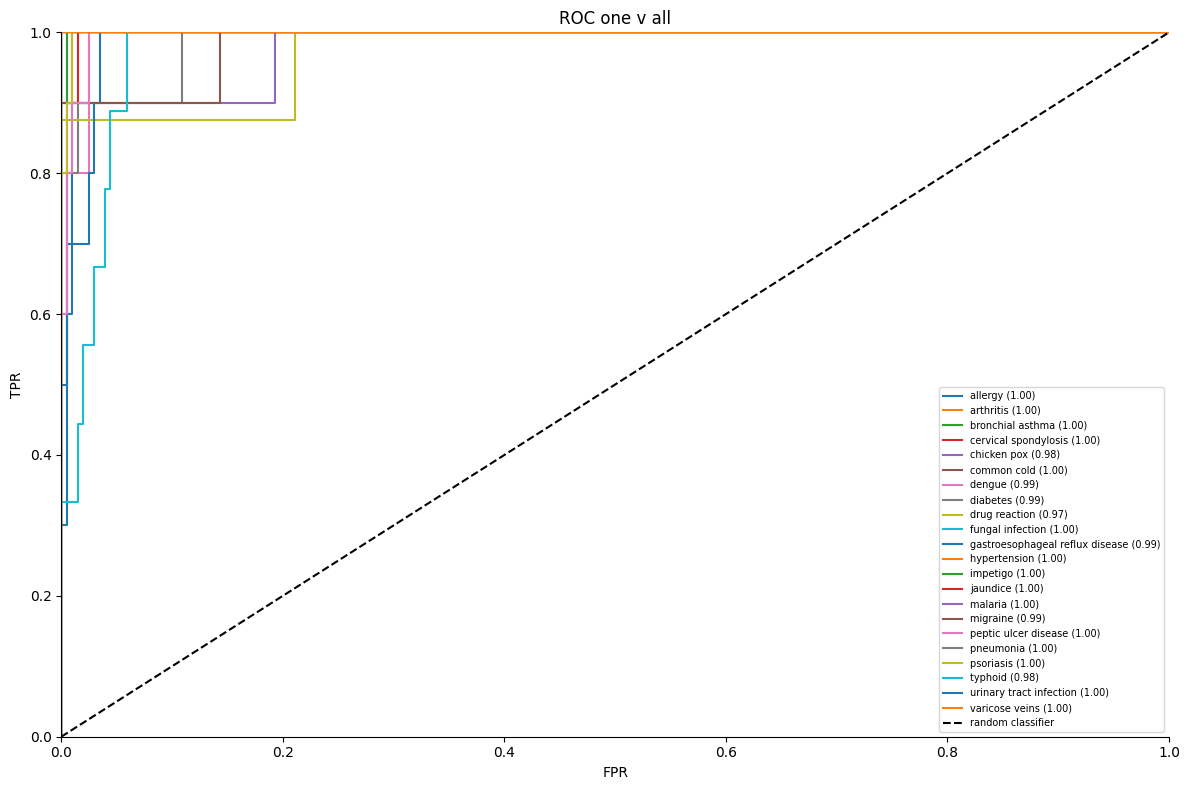

In [ ]:
import numpy as np

import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
# all metrics: https://scikit-learn.org/stable/api/sklearn.metrics.html
from sklearn.metrics import accuracy_score, auc, classification_report, roc_auc_score, f1_score, confusion_matrix, roc_curve,precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

data = load_dataset("gretelai/symptom_to_diagnosis") #hugging face dataset
train_symptoms, train_label = data["train"]["input_text"], data["train"]["output_text"]
test_symptoms, test_label= data["test"]["input_text"], data["test"]["output_text"]
train_df = pd.DataFrame(data["train"])
test_df = pd.DataFrame(data["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# parameter documentation https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
vec = TfidfVectorizer(max_features=500)
train_symptoms = vec.fit_transform(train_symptoms)
test_symptoms = vec.transform(test_symptoms)

# all parameters https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
logreg = OneVsRestClassifier(LogisticRegression(solver="lbfgs", random_state=42, max_iter=1000))
logreg.fit(train_symptoms, train_label)
clf = logreg.predict(test_symptoms)

# one v all for multinom
from sklearn.preprocessing import label_binarize
classes = logreg.classes_
binary_matrix = label_binarize(test_label, classes=classes)
proba = logreg.predict_proba(test_symptoms)

auc_score = roc_auc_score(binary_matrix, proba, average='weighted', multi_class='ovr')
f1 = f1_score(test_label, clf, average='weighted')
precision = precision_score(test_label, clf, average='weighted')
recall = recall_score(test_label, clf, average='weighted')

print('logreg:', logreg)
print("accuracy:", accuracy_score(test_label, clf))
print('f1 score:', f1, "AUC score", auc_score)
print('Overall precision:', precision)
print('Overall recall:', recall)

# eval overfitting/under
train_pred = logreg.predict(train_symptoms)
train_accuracy = accuracy_score(train_label, train_pred)
train_f1 = f1_score(train_label, train_pred, average='weighted')

test_accuracy = accuracy_score(test_label, clf)
test_f1 = f1_score(test_label, clf, average='weighted')

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Gap", train_accuracy - test_accuracy)


print(classification_report(test_label, clf))
#print('confusion matrix', confusion_matrix(test_label, clf))


plt.figure(figsize=(12, 8))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(binary_matrix[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=f"{c} ({auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC one v all")
plt.legend(loc="lower right", fontsize=7)
sns.despine()
plt.tight_layout()
plt.show()



